In [20]:
pip install torch torchvision matplotlib pillow

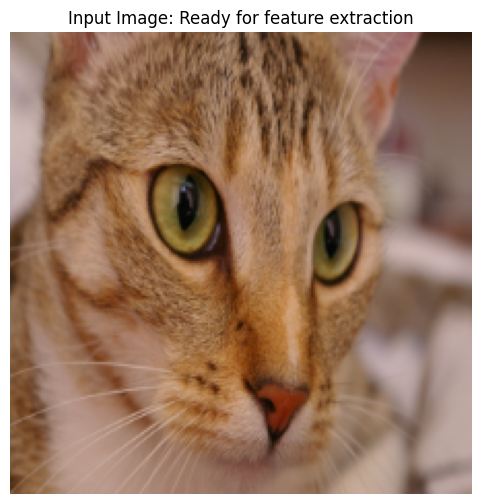

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data,color, transform
#Load a built-in high quality image (cat)
img_raw = data.cat()
img = transform.resize(img_raw, (224,224))

plt.figure(figsize = (6,6))
plt.imshow(img, cmap = 'gray')
plt.title('Input Image: Ready for feature extraction')
plt.axis('off')
plt.show()

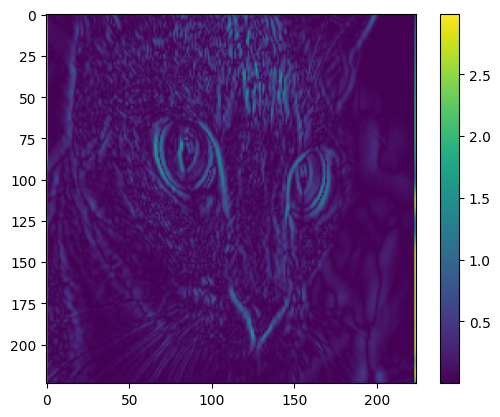

In [22]:
#the 'Neuron' Filter (Sobel operator for vertical edges)
# this 3*3 matrix is ewhst the CNN 'leanrs' during trainning
kernel = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0 ,1]
])
#convert to image to grayscale to make it 2d
img_gray = color.rgb2gray(img)
#simulating the activation map
from scipy.signal import convolve2d
feature_map = convolve2d(img_gray, kernel, mode = 'same')

plt.imshow(np.absolute(feature_map), cmap = 'viridis')
plt.colorbar()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step


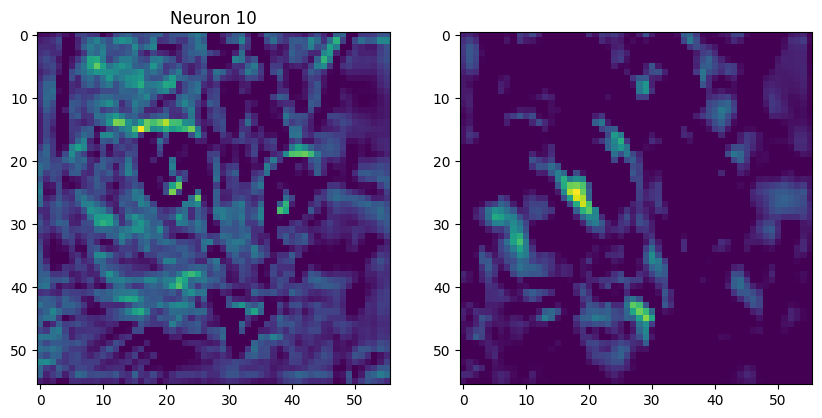

In [25]:
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from skimage import data, transform
import numpy as np
import matplotlib.pyplot as plt

#Load VGG16 (pre-trained on ImageNet)
model = VGG16(weights = 'imagenet', include_top = "False")

#prepare cat image
img_raw = data.cat()
cat_resized = transform.resize(img_raw, (224, 224))
x = np.expand_dims(cat_resized*255, axis = 0) #VGG expects 0-255 range
x = preprocess_input(x)

#extract mid-level layer (bloack 3, conv 1)
# this layer is deep enough to ee texturees but not 'objects'
mid_layer_model = tf.keras.Model(inputs = model.input, outputs = model.get_layer('block3_conv1').output)
mid_features = mid_layer_model.predict(x)

#vusualize the 10th and 15th filters (neurons)
fig, ax = plt.subplots(1,2, figsize = (10,10))
ax[0].imshow(mid_features[0,:,:,10], cmap = 'viridis')
ax[0].set_title('Neuron 10')
ax[1].imshow(mid_features[0,:,:,15], cmap = 'viridis')

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


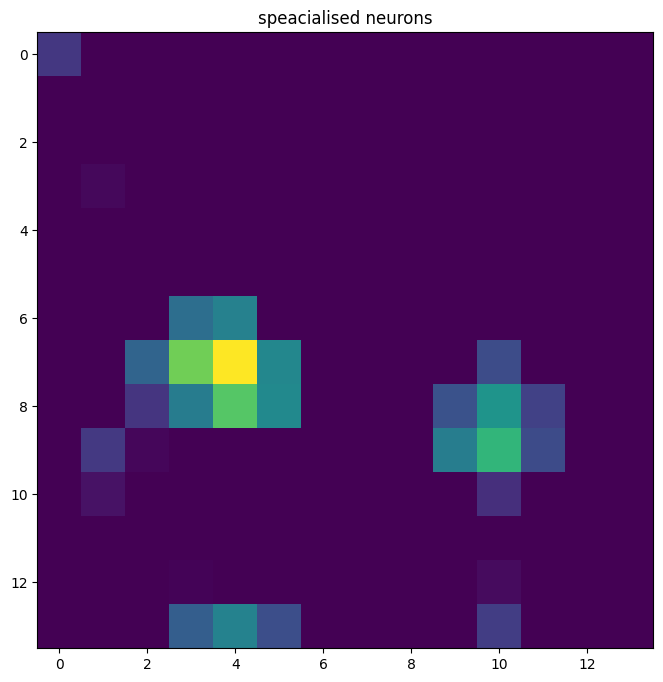

In [27]:
# extract the final convolution layer(block 5, covnvo 3)
deep_layer_model = tf.keras.Model(inputs = model.input, outputs = model.get_layer('block5_conv3').output)
deep_features = deep_layer_model.predict(x)

#2. find a 'specialist' neuron
#in deep learning, many filters will be blank, but some will 'glow' intensely
#on specific partd of the astrants's image
plt.figure(figsize = (8,8))
plt.imshow(deep_features[0,:,:, 10], cmap = 'viridis')
plt.title('speacialised neurons')
plt.show()